In [2]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

from ciim.src.common import datasets_e, datasets_a, datasets_all, cell_types, surrogate_names, colors_blind, palette_cell_types, palette_datasets, palette_datasets_pretty, palette_genders, palette_minor_types



plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")



# Extend collecTRI by adding indivitual sources to edges

In [8]:
from ciim.src.utils.util import flesh_out_collectri
flesh_out_collectri()

In [9]:
curated_net = pd.read_csv('/vol/projects/jnourisa/prior/collectri_with_source.csv')
curated_net['ref'].unique()

array(['DoRothEA-A', 'ExTRI', 'HTRI', 'Pavlidis2021', 'TFactS', 'TRRUST',
       'GEREDB', 'CytReg', 'SIGNOR', 'GOA', 'IntAct'], dtype=object)

# Valid gene names

In [4]:
# def get_known_gene_names():
if True:
    import pandas as pd
    gtf_cols = [
        'seqname', 'source', 'feature', 'start', 'end',
        'score', 'strand', 'frame', 'attribute'
    ]

    gtf_path = '/home/jnourisa/projs/ongoing/task_grn_inference/resources/supp_data/gencode.v47.annotation.gtf.gz'

    gtf_df = pd.read_csv(
        gtf_path,
        sep='\t',
        compression='gzip',
        comment='#',
        header=None,
        names=gtf_cols,
        engine='python'
    )
    import re

    # Define known chromosomes (as strings)
    known_chromosomes = [f'chr{i}' for i in range(1, 21)] + ['X', 'Y']

    # Filter rows where feature is 'gene' and on a known chromosome
    genes_df = gtf_df[
        (gtf_df['feature'] == 'gene') &
        (gtf_df['seqname'].isin(known_chromosomes))
    ].copy()

    # Function to extract gene_name from the attribute column
    def extract_gene_name(attr_str):
        match = re.search(r'gene_name "([^"]+)"', attr_str)
        return match.group(1) if match else None

    # Apply the function
    genes_df['gene_name'] = genes_df['attribute'].apply(extract_gene_name)
    print(genes_df['gene_name'].nunique())

    # Drop NA (just in case) and get unique gene names
    gene_names = genes_df['gene_name'].dropna().unique().tolist()
    np.savetxt(
        '/vol/projects/jnourisa/prior/gene_names.txt',
        gene_names,
        fmt='%s'
    )
# get_known_gene_names()

70759


In [5]:
gtf_df['attribute'].

,seqname,source,feature,start,end,score,strand,frame,attribute
0,chr1,HAVANA,gene,11121,24894,.,+,.,"gene_id ""ENSG00000290825.2""; gene_type ""lncRNA..."
1,chr1,HAVANA,transcript,11121,14413,.,+,.,"gene_id ""ENSG00000290825.2""; transcript_id ""EN..."
2,chr1,HAVANA,exon,11121,11211,.,+,.,"gene_id ""ENSG00000290825.2""; transcript_id ""EN..."
3,chr1,HAVANA,exon,12010,12227,.,+,.,"gene_id ""ENSG00000290825.2""; transcript_id ""EN..."
4,chr1,HAVANA,exon,12613,12721,.,+,.,"gene_id ""ENSG00000290825.2""; transcript_id ""EN..."
...,...,...,...,...,...,...,...,...,...
4105480,chrM,ENSEMBL,transcript,15888,15953,.,+,.,"gene_id ""ENSG00000210195.2""; transcript_id ""EN..."
4105481,chrM,ENSEMBL,exon,15888,15953,.,+,.,"gene_id ""ENSG00000210195.2""; transcript_id ""EN..."
4105482,chrM,ENSEMBL,gene,15956,16023,.,-,.,"gene_id ""ENSG00000210196.2""; gene_type ""Mt_tRN..."
4105483,chrM,ENSEMBL,transcript,15956,16023,.,-,.,"gene_id ""ENSG00000210196.2""; transcript_id ""EN..."


# Promotor based skeleton

In [2]:
net1 = pd.read_csv(f'/home/jnourisa/projs/ongoing/task_grn_inference/output/skeleton/skeleton_encode_promotor.csv')
net1['edge'] = net1['source'] + '_' + net1['target']

net2 = pd.read_csv(f'/home/jnourisa/projs/ongoing/task_grn_inference/output/skeleton/skeleton_jaspar_promotor.csv')
net2['edge'] = net2['source'] + '_' + net2['target']



In [9]:
net = pd.concat([net1, net2])
net.drop_duplicates(subset=['edge'], inplace=True)
net = net[['source', 'target', 'edge']].reset_index(drop=True)

In [11]:
net.to_csv(f'/vol/projects/jnourisa/prior/skeleton_promotor.csv', index=False)

# For the overview figure

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Example data with more TFs
df = pd.DataFrame({
    'TF': ['SPI1', 'IRF8', 'CEBPB', 'GATA2', 'FOXP1', 'STAT3', 
           'KLF6', 'BATF3', 'ETS1', 'NFATC2', 'NFKB1', 'KLF4'],
    'Importance': [0.9, 0.85, 0.78, 0.75, 0.72, 0.70, 0.68, 0.65, 0.6, 0.58, 0.55, 0.5]
})

# Sort values for better visualization
df = df.sort_values(by='Importance', ascending=True)

# Create color gradient based on importance
norm = plt.Normalize(df['Importance'].min(), df['Importance'].max())
colors = sns.color_palette("Reds", as_cmap=True)(norm(df['Importance']))

# Plot
plt.figure(figsize=(1.5, 3))
ax = sns.barplot(data=df, y='TF', x='Importance', palette=colors)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Importance')
plt.ylabel('TF')
# plt.title('Robust predictors of age')

plt.show()

# Create Pseudocell


In [ ]:

dataset = 'data12' #CXCL9 


def assign_metacells(df, groupby_col, metacell_size=15):
    df = df.copy()
    metacell_id = np.empty(len(df), dtype=object)

    # Create a Series of indices to preserve order
    for group in df[groupby_col].unique():
        mask = df[groupby_col] == group
        idx = np.flatnonzero(mask)
        n_metacells = int(np.ceil(len(idx) / metacell_size))
        ids = np.repeat([f"{group}_MC{i}" for i in range(n_metacells)], metacell_size)[:len(idx)]
        metacell_id[idx] = ids

    df['metacell_id'] = metacell_id
    return df

def normalize(adata):
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    return adata
def create_metacell(adata, sum_by_col):
    from task_grn_inference.src.utils.util import sum_by
    adata.obs[sum_by_col] = adata.obs[sum_by_col].astype('category')
    print(adata.obs[sum_by_col].nunique())
    adata_bulk = sum_by(adata, sum_by_col, unique_mapping=True)
    adata_bulk = normalize(adata_bulk)

    # merge the remaining metadata
    adata_bulk.obs['__original_index__'] = adata_bulk.obs.index
    merged_obs = adata_bulk.obs.merge(
        adata.obs,
        on=sum_by_col,
        how='left',
        suffixes=('', '_from_single')
    )
    merged_obs = merged_obs.drop_duplicates(subset=sum_by_col, keep='last')
    merged_obs = merged_obs.set_index('__original_index__').loc[adata_bulk.obs.index]
    adata_bulk.obs = merged_obs
    return adata_bulk

def main_metacell(dataset):
    # - read the data
    adata = ad.read_h5ad(f'/vol/projects/jnourisa/datasets/{dataset}_sc.h5ad')
    adata = adata[ ~adata.obs.isna().any(axis=1), :]
    # - group by before metacells
    cols = ['cell_type', 'dataset', 'donor_id', 'age', 'treatment']
    available_cols = [col for col in cols if col in adata.obs.columns]
    adata.obs['groupby_col'] = adata.obs[available_cols].astype(str).agg('_'.join, axis=1)

    # - assign metacells
    adata.obs = assign_metacells(adata.obs, groupby_col='groupby_col', metacell_size=15)
    adata.obs.head()[['groupby_col', 'metacell_id']]

    # - create metacells
    adata_metacell = create_metacell(adata, sum_by_col='metacell_id')

    # - save
    cols = ['dataset', 'sex', 'donor_id', 'age', 'cell_type']
    if 'treatment' in adata_metacell.obs.columns:
        cols.append('treatment')
    if 'disease' in adata_metacell.obs.columns:
        cols.append('disease')
    adata_metacell.obs = adata_metacell.obs[cols]
    print(adata_metacell.shape)
    adata_metacell.write(f'/vol/projects/jnourisa/datasets/{dataset}_metacell.h5ad')
for dataset in ['SLE_Asian', 'data7_allTPs_jalil', 'data13_Korean' , 'data13_Japanese']:
    print(dataset)
    main_metacell(dataset)
sc.pp.highly_variable_genes(adata_metacell, n_top_genes=2000, subset=True)
sc.pp.neighbors(adata_metacell)
sc.tl.umap(adata_metacell)
sc.pl.pca(adata_metacell, color=['cell_type'])

# Meta analysis schematic

Spearman correlations per cohort:

Meta-analysis combined p-value (Fisher's method): 6.258559317395964e-94


Text(0, 0.5, 'TF activity')

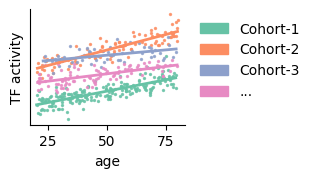

In [21]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, combine_pvalues
import matplotlib.pyplot as plt

# Step 1: Generate random data
np.random.seed(42)  # for reproducibility

n_samples_list = [200, 100, 60, 100]  # number of samples per cohort
cohorts = [f'Cohort-{i+1}' for i in range(3)]
cohorts.append('...')

data = []

# Define base slope and intercept
base_slope = 0.05
base_intercept = 0.5

for i,cohort in enumerate(cohorts):
    n_samples = n_samples_list[i]
    ages = np.random.uniform(20, 80, size=n_samples)
    
    # Slight random shifts in slope and intercept for each cohort
    slope_shift = np.random.normal(0, 0.02)
    intercept_shift = np.random.normal(0, 4)
    
    tf_activity = (base_slope + slope_shift) * ages + (base_intercept + intercept_shift)
    tf_activity += np.random.normal(0, 0.5, size=n_samples)  # add noise
    
    cohort_df = pd.DataFrame({
        'cohort': cohort,
        'age': ages,
        'tf_activity': tf_activity
    })
    
    data.append(cohort_df)

# Combine into one dataframe
data_df = pd.concat(data, ignore_index=True)
data_df['cohort'] = data_df['cohort'].astype(pd.CategoricalDtype(categories=cohorts, ordered=True))
# Step 2: Calculate Spearman correlation per cohort
results = []
for cohort in cohorts:
    subset = data_df[data_df['cohort'] == cohort]
    corr, pval = spearmanr(subset['age'], subset['tf_activity'])
    results.append({'cohort': cohort, 'spearman_corr': corr, 'pval': pval})

results_df = pd.DataFrame(results)
print("Spearman correlations per cohort:")
_, combined_pval = combine_pvalues(results_df['pval'])

print("\nMeta-analysis combined p-value (Fisher's method):", combined_pval)

# (Optional) Step 4: Plotting
import seaborn as sns
colors = list(palette_datasets.values())
fig, ax = plt.subplots(figsize=(2, 1.5))
for i, cohort in enumerate(data_df['cohort'].unique()):
    subset = data_df[data_df['cohort'] == cohort]
    sns.regplot(data=subset, x='age', y='tf_activity', ax=ax, 
                scatter_kws={'s': 2}, line_kws={'linewidth':2},
                color=colors[i], label=cohort, ci=None)

# ax.legend(title='Cohort', loc=(1.1, .2), frameon=False)
p_values = [1E-20, 1E-10, 1E-5, 1E-2]
legend_handles = []
for i, d in enumerate(cohorts):
    p_value = p_values[i]
    legend_label = d 
    # legend_label = '    ' + d +'\n' + r' (p:' + "{:.1e}".format(p_value) + ")"

    handle = mpatches.Patch(color=colors[i], label=legend_label)
    legend_handles.append(handle)
ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.set_yticks([])
ax.set_ylabel('TF activity')
# plt.title('Meta correlation analysis', pad=20)